Fig5E


Reading and merging data...
Skipping incomplete group: {'ctrl': '120-450-1000', 'neuronal': '120-450-1000_delay_shuffle_neuronal', 'synaptic': '120-450-1000_delay_shuffle_synaptic'}
Skipping incomplete group: {'ctrl': '120-400-1000', 'neuronal': '120-400-1000_delay_shuffle_neuronal', 'synaptic': '120-400-1000_delay_shuffle_synaptic'}
Remaining after filtering (Ctrl >= 0.8): 270
Original vs Neuronal P: 2.0473694814783555e-173
Neuronal vs Synaptic P: 0.0010152162384474822
Original vs Synaptic P: 9.269639203997668e-194


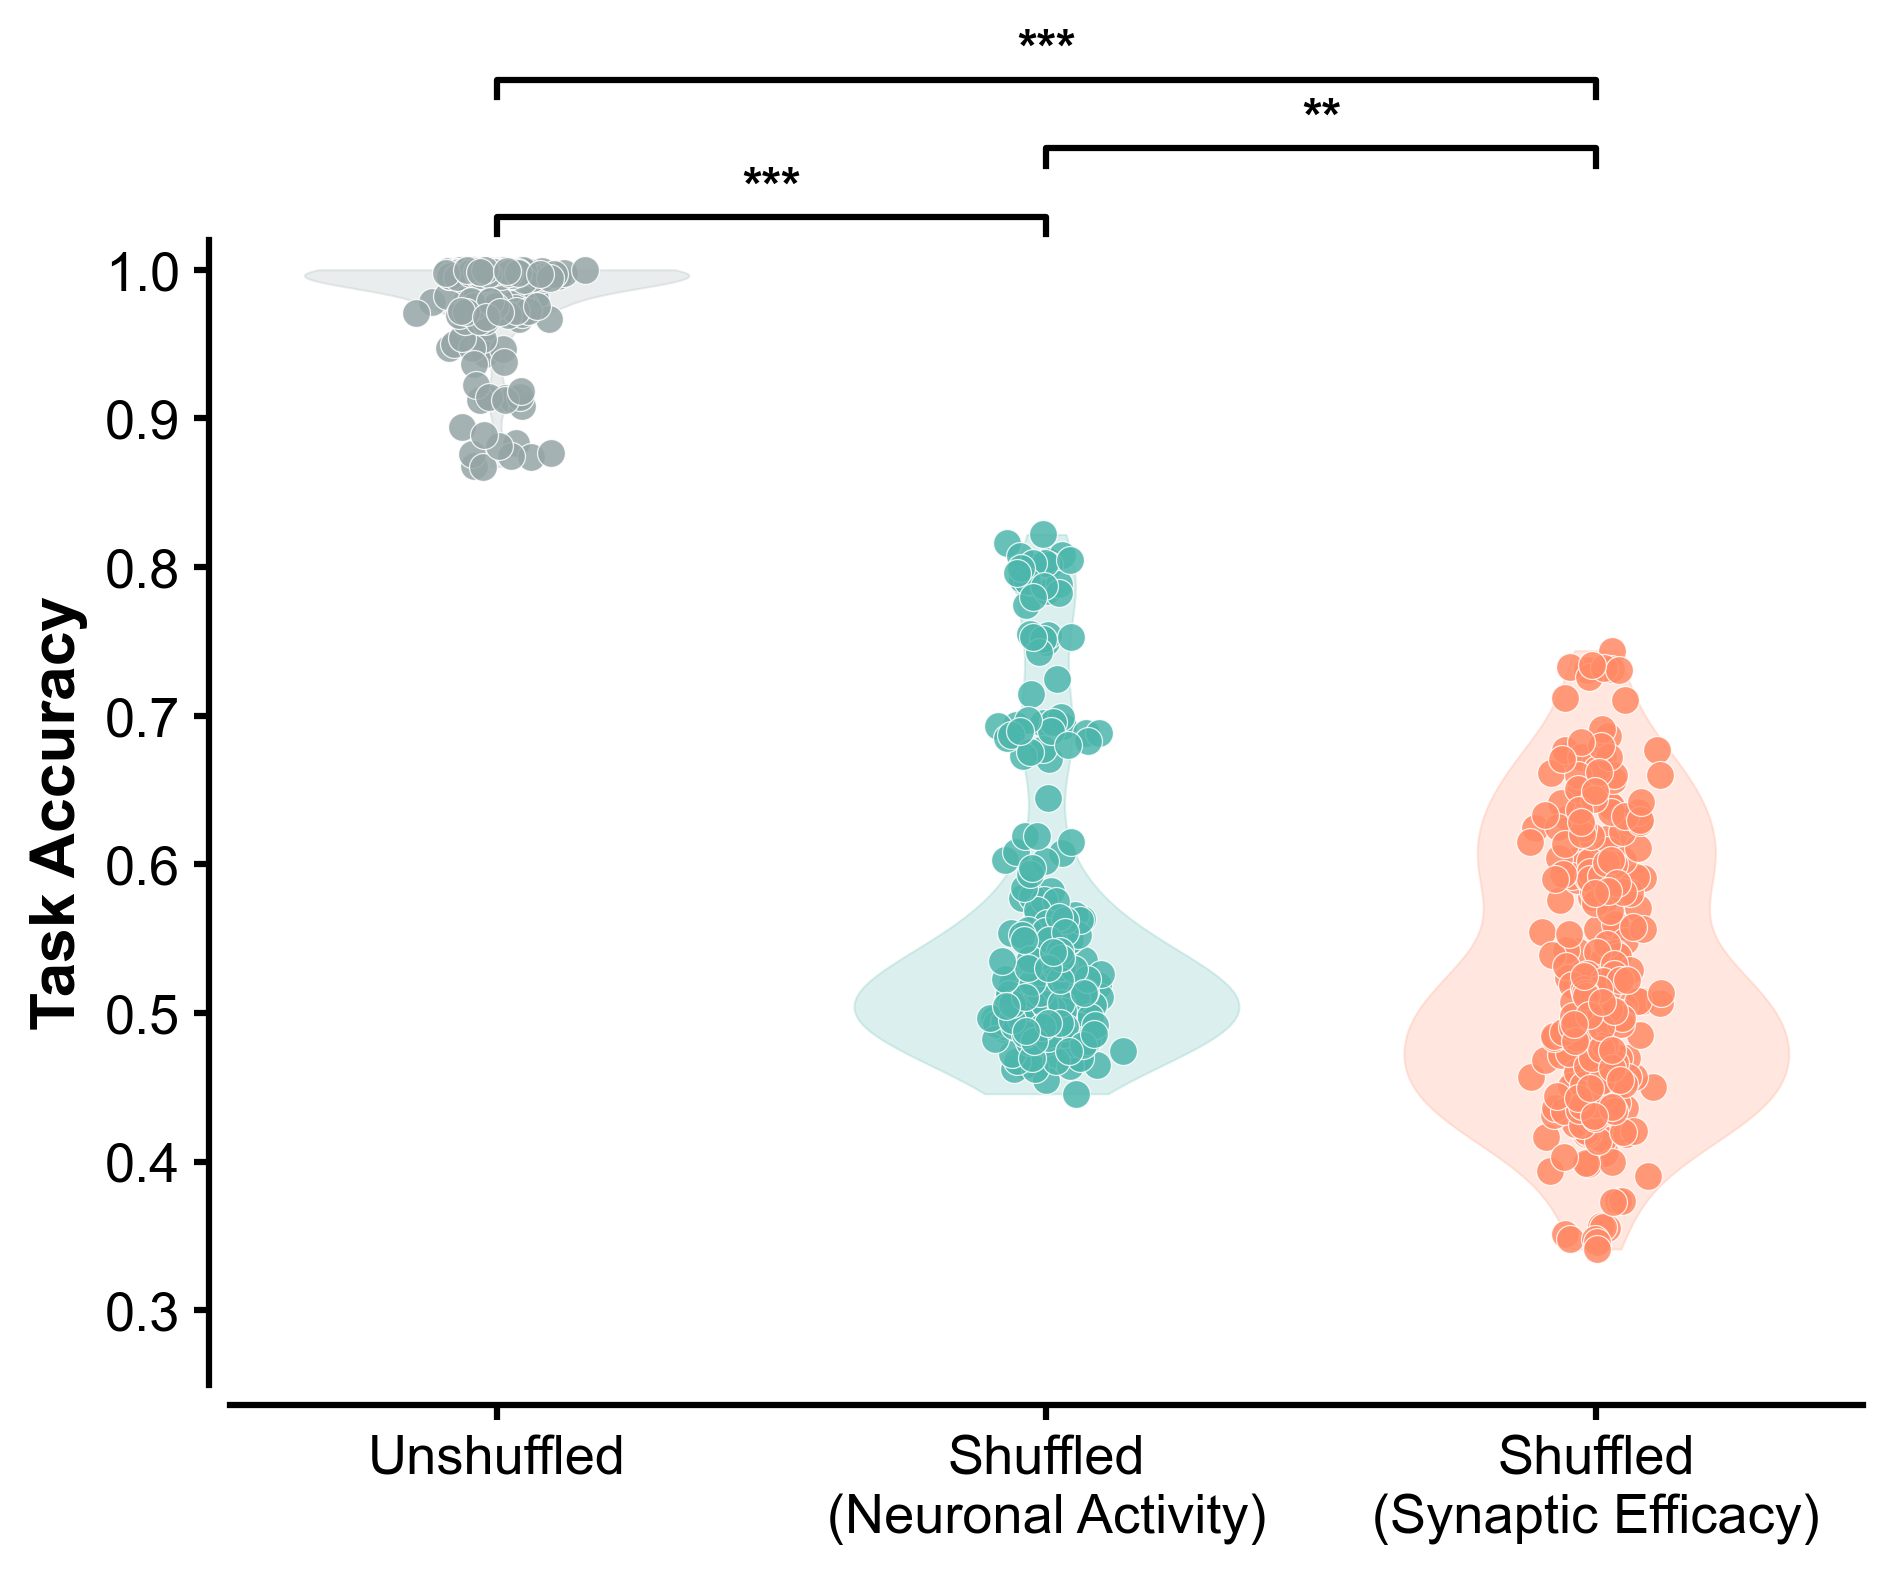

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import glob
import json
import os

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "Arial"

# ==========================================
# 1. Configuration
# ==========================================
base_dir = r'./total_results'

experiment_groups = [
    {
        'ctrl': '140-450-1000',
        'neuronal': '140-450-1000_delay_shuffle_neuronal',
        'synaptic': '140-450-1000_delay_shuffle_synaptic'
    },
    {
        'ctrl': '140-500-1000',
        'neuronal': '140-500-1000_delay_shuffle_neuronal',
        'synaptic': '140-500-1000_delay_shuffle_synaptic'
    },
    {
        'ctrl': '140-400-1000',
        'neuronal': '140-400-1000_delay_shuffle_neuronal',
        'synaptic': '140-400-1000_delay_shuffle_synaptic'
    },
    {
        'ctrl': '140-350-1000',
        'neuronal': '140-350-1000_delay_shuffle_neuronal',
        'synaptic': '140-350-1000_delay_shuffle_synaptic'
    },
    {
        'ctrl': '120-500-1000',
        'neuronal': '120-500-1000_delay_shuffle_neuronal',
        'synaptic': '120-500-1000_delay_shuffle_synaptic'
    },
    {
        'ctrl': '120-450-1000',
        'neuronal': '120-450-1000_delay_shuffle_neuronal',
        'synaptic': '120-450-1000_delay_shuffle_synaptic'
    },
    {
        'ctrl': '120-400-1000',
        'neuronal': '120-400-1000_delay_shuffle_neuronal',
        'synaptic': '120-400-1000_delay_shuffle_synaptic'
    },
    {
        'ctrl': '120-350-1000',
        'neuronal': '120-350-1000_delay_shuffle_neuronal',
        'synaptic': '120-350-1000_delay_shuffle_synaptic'
    },
    {
        'ctrl': '100-500-1000',
        'neuronal': '100-500-1000_delay_shuffle_neuronal',
        'synaptic': '100-500-1000_delay_shuffle_synaptic'
    },
    {
        'ctrl': '100-450-1000',
        'neuronal': '100-450-1000_delay_shuffle_neuronal',
        'synaptic': '100-450-1000_delay_shuffle_synaptic'
    },
    {
        'ctrl': '100-400-1000',
        'neuronal': '100-400-1000_delay_shuffle_neuronal',
        'synaptic': '100-400-1000_delay_shuffle_synaptic'
    },
    {
        'ctrl': '100-350-1000',
        'neuronal': '100-350-1000_delay_shuffle_neuronal',
        'synaptic': '100-350-1000_delay_shuffle_synaptic'
    }
]


plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['font.size'] = 13

colors = ['#95A5A6', '#4DB6AC', '#FF8A65']  

# ==========================================
# 2. Helper Functions
# ==========================================

def load_folder_data(folder_name):
    full_path = os.path.join(base_dir, folder_name)
    json_pattern = os.path.join(full_path, "*.json")
    files = glob.glob(json_pattern)
    all_data = []
    
    for f_path in files:
        try:
            with open(f_path, 'r', encoding='utf-8') as f:
                content = json.load(f)
                if 'all_seed_results' in content:
                    for seed_res in content['all_seed_results']:
                        row = {
                            'seed': seed_res.get('meta', {}).get('seed'),
                            'model_dir_name': seed_res.get('meta', {}).get('model_dir_name'),
                            'All_Conditions': seed_res['results'].get('All_Conditions')
                        }
                        all_data.append(row)
        except Exception:
            pass
    return pd.DataFrame(all_data)

def add_significance_bar(ax, x1, x2, y, p_value):
    h = 0.015
    if p_value >= 0.05: text = 'n.s.'
    elif p_value < 0.001: text = '***'
    elif p_value < 0.01: text = '**'
    elif p_value < 0.05: text = '*'
    else: text = 'n.s.'
    
    ax.plot([x1, x1, x2, x2], [y-h, y, y, y-h], lw=1.5, c='k')
    ax.text((x1 + x2) * 0.5, y + 0.002, text, ha='center', va='bottom', color='k', fontsize=12, fontweight='bold')

# ==========================================
# 3. Data Processing
# ==========================================
all_merged_data = []

print("Reading and merging data...")
for group in experiment_groups:
    df_ctrl = load_folder_data(group['ctrl'])
    df_neuronal = load_folder_data(group['neuronal'])
    df_synaptic = load_folder_data(group['synaptic'])
    
    if df_ctrl.empty or df_neuronal.empty or df_synaptic.empty:
        print(f"Skipping incomplete group: {group}")
        continue

    merge_keys = ['model_dir_name', 'seed']
    df_step1 = pd.merge(df_ctrl, df_neuronal, on=merge_keys, suffixes=('_ctrl', '_neuronal'))
    df_final = pd.merge(df_step1, df_synaptic, on=merge_keys)
    df_final.rename(columns={'All_Conditions': 'All_Conditions_synaptic'}, inplace=True)
    all_merged_data.append(df_final)

if not all_merged_data:
    print("No valid data found.")
else:
    final_df = pd.concat(all_merged_data, ignore_index=True)

    threshold = 0.8
    criterion = final_df['All_Conditions_ctrl'] >= threshold
    final_df = final_df[criterion].copy()
    print(f"Remaining after filtering (Ctrl >= {threshold}): {len(final_df)}")

    if len(final_df) == 0:
        print("No data left after filtering.")
    else:
        # ==========================================
        # 4. Plotting (Aesthetic Violin Plot)
        # ==========================================
        fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=300)

        positions = [1, 2, 3]
        labels = ['Unshuffled', 'Shuffled\n(Neuronal Activity)', 'Shuffled\n(Synaptic Efficacy)']

        data_to_plot = [
            final_df['All_Conditions_ctrl'].dropna(),
            final_df['All_Conditions_neuronal'].dropna(),
            final_df['All_Conditions_synaptic'].dropna()
        ]

        parts = ax.violinplot(data_to_plot, positions=positions, showmeans=False, showextrema=False, widths=0.7)
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(colors[i])
            pc.set_edgecolor(colors[i])
            pc.set_linewidth(0.5)  
            pc.set_alpha(0.2)      

        np.random.seed(42)
        for i, (data, pos) in enumerate(zip(data_to_plot, positions)):
            x_jitter = np.random.normal(loc=0, scale=0.045, size=len(data))
            x_jitter = np.clip(x_jitter, -0.16, 0.16) 
            
            ax.scatter(np.full(len(data), pos) + x_jitter, data, 
                       color=colors[i], 
                       s=45,
                       alpha=0.85,
                       edgecolors='white',     
                       linewidth=0.3,
                       zorder=2)

        def add_significance_bar(ax, x1, x2, y_ax, p_value):
            h = 0.015
            if p_value >= 0.05:
                text = 'n.s.'
            elif p_value < 0.001:
                text = '***'
            elif p_value < 0.01:
                text = '**'
            else:
                text = '*'

            trans = ax.get_xaxis_transform()
            ax.plot([x1, x1, x2, x2], [y_ax-h, y_ax, y_ax, y_ax-h],
                    lw=1.5, c='k', transform=trans, clip_on=False)
            ax.text((x1 + x2) * 0.5, y_ax + 0.004, text,
                    ha='center', va='bottom', color='k', fontsize=12, fontweight='bold',
                    transform=trans, clip_on=False)
        
        _, p1 = stats.ttest_rel(final_df['All_Conditions_ctrl'], final_df['All_Conditions_neuronal'])
        _, p2 = stats.ttest_rel(final_df['All_Conditions_neuronal'], final_df['All_Conditions_synaptic'])
        _, p3 = stats.ttest_rel(final_df['All_Conditions_ctrl'], final_df['All_Conditions_synaptic'])

        add_significance_bar(ax, positions[0], positions[1], 1.02, p1)
        add_significance_bar(ax, positions[1], positions[2], 1.08, p2)
        add_significance_bar(ax, positions[0], positions[2], 1.14, p3)

        print(f"Original vs Neuronal P: {p1}")
        print(f"Neuronal vs Synaptic P: {p2}")
        print(f"Original vs Synaptic P: {p3}")

        ax.set_xticks(positions)
        ax.set_xticklabels(labels, fontsize=12)
        ax.set_ylabel('Task Accuracy', fontsize=15, fontweight='bold')
        
        ax.set_ylim(bottom=0.25, top=1.02)

        sns.despine(offset=5, trim=False)
        
        plt.tight_layout()
        
        plt.savefig('shuffle_3bars.pdf', dpi=300, transparent=True)
        plt.show()